In [1]:
import pickle
from collections import defaultdict 
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import umap
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
resolution = 16

df = pd.read_csv("../data/freesolv.csv")

print(len(df))

smiles = df["smiles"].tolist()

fd = FieldDataset(smiles, resolution=resolution)
dl = DataLoader(fd, batch_size=4, shuffle=True)
dl_test = DataLoader(fd, batch_size=8, shuffle=False)

642


In [3]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=4,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=10,
    output_shape=[resolution, resolution, resolution, 10, 1],
    latent_dim=512,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

# Load the model
autoencoder.load_state_dict(torch.load("../models/freesolv_b.pt", weights_only=True))
autoencoder.cuda()

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Autoencoder(
  (net): SirenNet(
    (layers): ModuleList(
      (0-3): 4 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
  (encoder): Encoder(
    (in_layer): Conv3d(10, 20, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_input): BatchNorm3d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (layer_1): Conv3d(20, 40, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_1): BatchNorm3d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (out_layer): Conv3d(40, 512, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_output): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pooling): AdaptiveAvgPool3d(output_size=1)
  )
  (modulator): Modulator(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): ReLU()
      )
      

In [4]:
def calculate_psnr(original, compressed):
    original = original.astype(np.float32)
    compressed = compressed.astype(np.float32)
    
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

In [5]:
i = 0
total_psnr = 0.0
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    predictions = autoencoder.predict(latents).cpu().detach().squeeze(-1).numpy()
    for pred in predictions:
        total_psnr += calculate_psnr(pred, fd[i].cpu().detach().numpy())
        i += 1

print(total_psnr / len(fd))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 81/81 [00:06<00:00, 13.10it/s]

28.688145


yt : [INFO     ] 2025-02-12 10:23:23,087 Parameters: current_time              = 0.0                                                                                                                                                                                | 0/81 [00:00<?, ?it/s]
yt : [INFO     ] 2025-02-12 10:23:23,087 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-12 10:23:23,087 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 10:23:23,087 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 10:23:23,088 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 10:23:23,149 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 10:23:23,156 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 10:23:23,157 Creating volume
yt : [INFO     ] 2025-02-12 10:23:23,173 Creating transfer function
yt : [INFO     ] 2025-02-12 10:23:23,173 Calculating data bounds. This

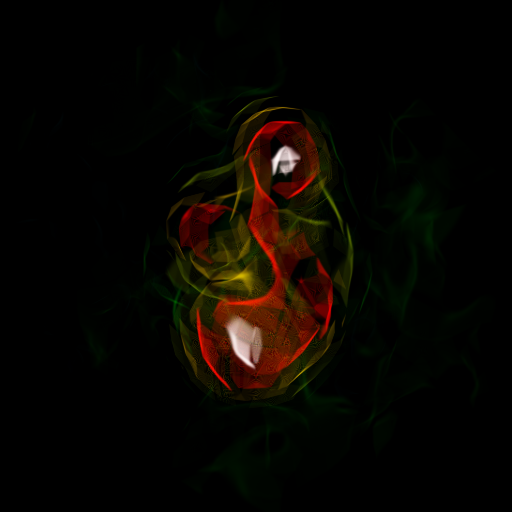

yt : [INFO     ] 2025-02-12 10:23:23,334 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 10:23:23,335 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-12 10:23:23,335 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 10:23:23,335 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 10:23:23,336 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 10:23:23,378 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 10:23:23,385 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 10:23:23,386 Creating volume
yt : [INFO     ] 2025-02-12 10:23:23,401 Creating transfer function
yt : [INFO     ] 2025-02-12 10:23:23,401 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


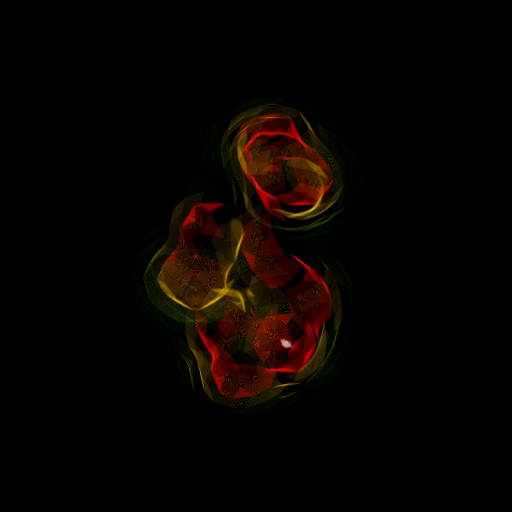

yt : [INFO     ] 2025-02-12 10:23:23,535 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 10:23:23,536 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-12 10:23:23,536 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 10:23:23,536 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 10:23:23,536 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 10:23:23,579 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 10:23:23,585 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 10:23:23,586 Creating volume
yt : [INFO     ] 2025-02-12 10:23:23,601 Creating transfer function
yt : [INFO     ] 2025-02-12 10:23:23,601 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


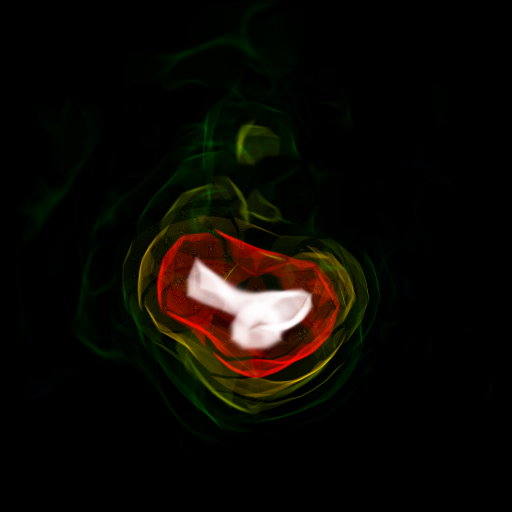

yt : [INFO     ] 2025-02-12 10:23:23,752 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 10:23:23,752 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-12 10:23:23,752 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 10:23:23,752 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 10:23:23,752 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 10:23:23,796 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 10:23:23,803 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 10:23:23,803 Creating volume
yt : [INFO     ] 2025-02-12 10:23:23,819 Creating transfer function
yt : [INFO     ] 2025-02-12 10:23:23,819 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


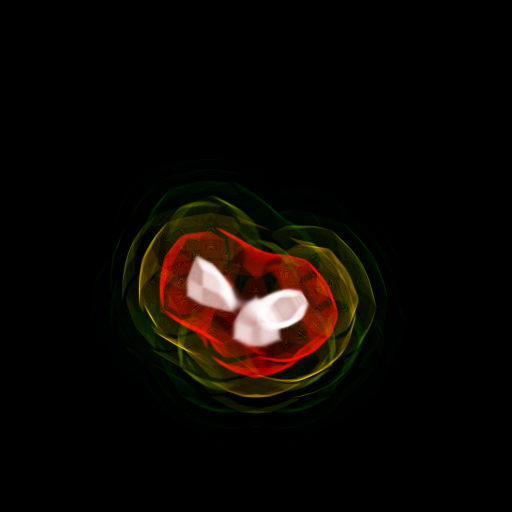

yt : [INFO     ] 2025-02-12 10:23:23,962 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 10:23:23,962 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-12 10:23:23,963 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 10:23:23,963 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 10:23:23,963 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 10:23:24,094 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 10:23:24,101 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 10:23:24,101 Creating volume
yt : [INFO     ] 2025-02-12 10:23:24,116 Creating transfer function
yt : [INFO     ] 2025-02-12 10:23:24,116 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


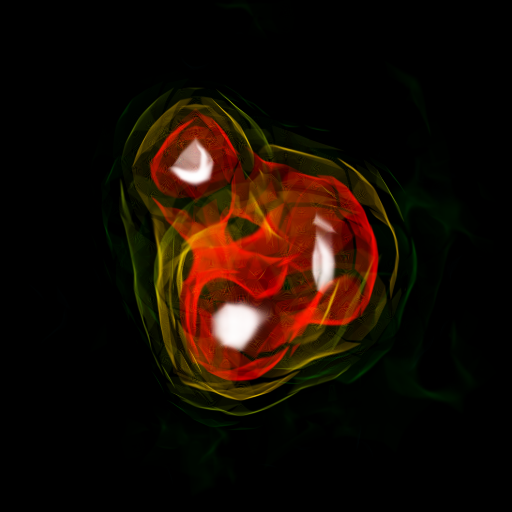

yt : [INFO     ] 2025-02-12 10:23:24,265 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 10:23:24,266 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-12 10:23:24,266 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 10:23:24,266 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 10:23:24,266 Parameters: cosmological_simulation   = 0
  0%|                                                                                                                                                                                                                                                               | 0/81 [00:01<?, ?it/s]


gt


KeyboardInterrupt: 

In [6]:
x = []
i = 0

for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    predictions = autoencoder.predict(latents).cpu().detach().squeeze(-1)
    for pred in predictions:
        plot_field(pred[:, :, :, 0]).show()

        gt = fd[i]
        print("gt")
        plot_field(gt[:, :, :, 0]).show()
        i += 1
    break

In [7]:
x = []
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    for latent in latents:
        x.append(latent.cpu().detach().numpy())

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 81/81 [00:00<00:00, 343.78it/s]


In [8]:
y = df["freesolv"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1)
mlp = MLPRegressor(hidden_layer_sizes=(512,64,32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

Root Mean Squared Error: 3.0193580359349648
R^2 Score: 0.41721494663412617


/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


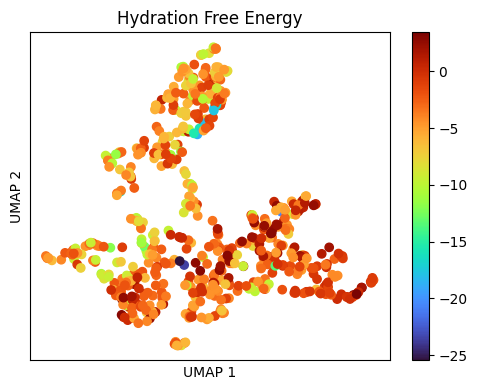

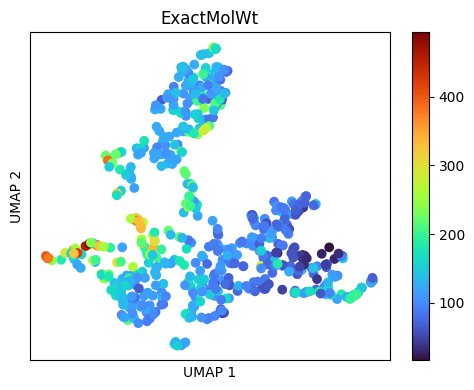

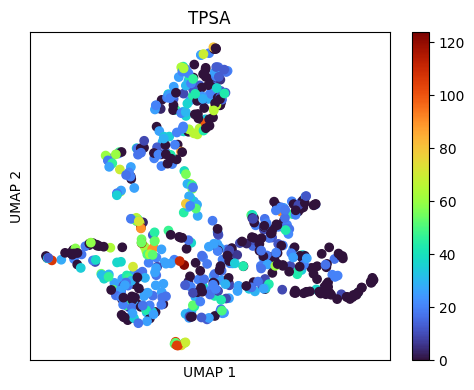

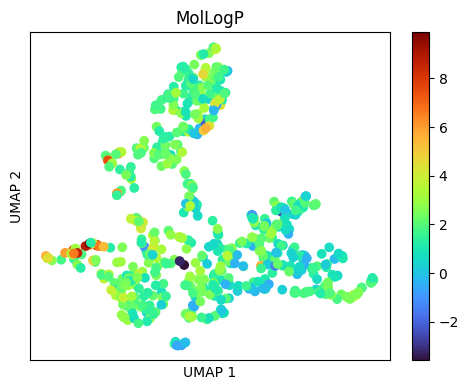

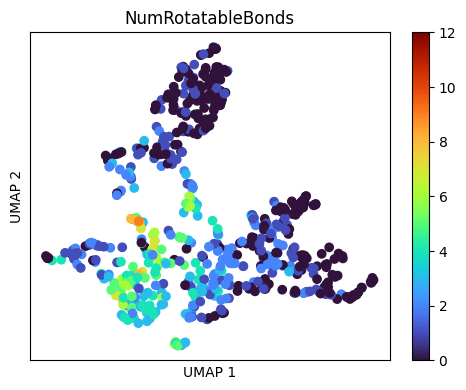

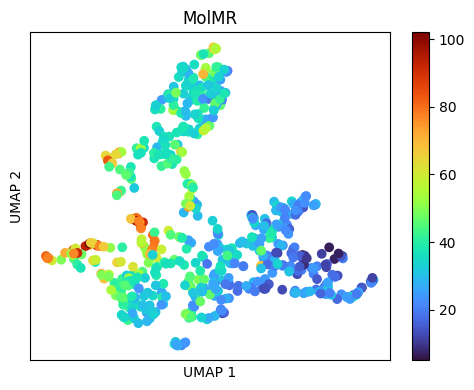

In [9]:
x_proj = umap.UMAP(n_neighbors=5).fit_transform(np.array(x))
y = df["freesolv"].to_numpy()
fig, ax = plt.subplots(figsize=(5, 4))

scatter = ax.scatter(x_proj.T[0], x_proj.T[1], c=y, cmap="turbo")
cbar = plt.colorbar(scatter, ax=ax)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.xticks([])
plt.yticks([])
plt.title("Hydration Free Energy")
plt.tight_layout()
plt.show()

fig.savefig("freesolv.png", dpi=300)

y = defaultdict(list)

for smi in df["smiles"].tolist():
    mol = Chem.MolFromSmiles(smi)
    y["ExactMolWt"].append(rdMolDescriptors.CalcExactMolWt(mol))

for smi in df["smiles"].tolist():
    mol = Chem.MolFromSmiles(smi)
    y["TPSA"].append(Descriptors.TPSA(mol))

for smi in df["smiles"].tolist():
    mol = Chem.MolFromSmiles(smi)
    y["MolLogP"].append(Descriptors.MolLogP(mol))

for smi in df["smiles"].tolist():
    mol = Chem.MolFromSmiles(smi)
    y["NumRotatableBonds"].append(Descriptors.NumRotatableBonds(mol))

for smi in df["smiles"].tolist():
    mol = Chem.MolFromSmiles(smi)
    y["MolMR"].append(Descriptors.MolMR(mol))

for key, value in y.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    
    scatter = ax.scatter(x_proj.T[0], x_proj.T[1], c=value, cmap="turbo")
    cbar = plt.colorbar(scatter, ax=ax)
    
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.xticks([])
    plt.yticks([])
    plt.title(key)
    plt.tight_layout()
    plt.show()

    fig.savefig(f"{key}.png", dpi=300)

In [4]:
def interp(arr1, arr2, num_points):
    fractions = np.linspace(0, 1, num_points)
    return np.array([arr1 + (arr2 - arr1) * f for f in fractions])

In [11]:
latents = []

for batch in dl_test:
    lats = autoencoder.encode(batch.cuda())
    for lat in lats:
        latents.append(lat.cpu().detach())

latents_intrp = interp(latents[1], latents[5], 48)
print(latents_intrp.shape, latents[0].shape)
for i, l in enumerate(latents_intrp):
    reconstructed = autoencoder.predict(torch.FloatTensor(np.array([l])).cuda())[0]
    reconstructed = reconstructed.cpu().detach().squeeze(-1)
    plot_field(reconstructed.flatten(3)[:, :, :, 0]).save(f"{i:05d}.png")

yt : [INFO     ] 2025-02-12 10:36:47,175 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 10:36:47,175 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-12 10:36:47,175 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 10:36:47,176 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 10:36:47,176 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 10:36:47,219 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-12 10:36:47,225 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-12 10:36:47,225 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 10:36:47,226 Creating volume
yt : [INFO     ] 2025-02-12 10:36:47,241 Creating transfer function
yt : [INFO     ] 2025-02-12 10:36:47,242 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.
yt : [INFO     ] 2025-02-12 10:36:4

(48, 512) torch.Size([512])


yt : [INFO     ] 2025-02-12 10:36:47,394 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 10:36:47,394 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-12 10:36:47,394 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 10:36:47,395 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 10:36:47,395 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 10:36:47,437 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-12 10:36:47,443 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-12 10:36:47,444 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 10:36:47,444 Creating volume
yt : [INFO     ] 2025-02-12 10:36:47,462 Creating transfer function
yt : [INFO     ] 2025-02-12 10:36:47,462 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.
yt : [INFO     ] 2025-02-12 10:36:4